In [2]:
# Pharmacy Inventory & Demand Analysis

## Project Objective

analyze pharmacy sales data to identify demand trends, top-selling products, seasonal patterns, and business insights 
that can help improve inventory management and reduce stock shortages.

## Project Objective

A regional pharmacy chain wants to understand medication demand patterns to improve inventory planning, reduce stock shortages, and support data-driven purchasing decisions.

This project analyzes daily pharmacy sales across multiple therapeutic drug categories using Python to identify trends, seasonal patterns, and actionable business insights.

In [9]:
## Import Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [11]:
## Load Dataset

In [25]:
df = pd.read_csv("Desktop/Pharmacy Inventory Demand Analysis/data/Pharma Sales Data/salesdaily.csv")

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [30]:
## Data Exploration

In [32]:
# Display dataset dimensions
print("Rows and Columns:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Summary statistics
df.describe()

Rows and Columns: (2106, 13)

Columns:
['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [34]:
# Check for missing values
df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [36]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
## Data Cleaning

In [38]:
# Convert date column to datetime format
df["datum"] = pd.to_datetime(df["datum"])

# Verify the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 214.0+ KB


In [15]:
## Exploratory Data Analysis (EDA)

Our first question is:

Which medication categories generate the highest overall sales?

In [41]:
# Medication category columns
drug_columns = ["M01AB", "M01AE", "N02BA", "N02BE",
                "N05B", "N05C", "R03", "R06"]

# Calculate total sales
total_sales = df[drug_columns].sum().sort_values(ascending=False)

print(total_sales)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


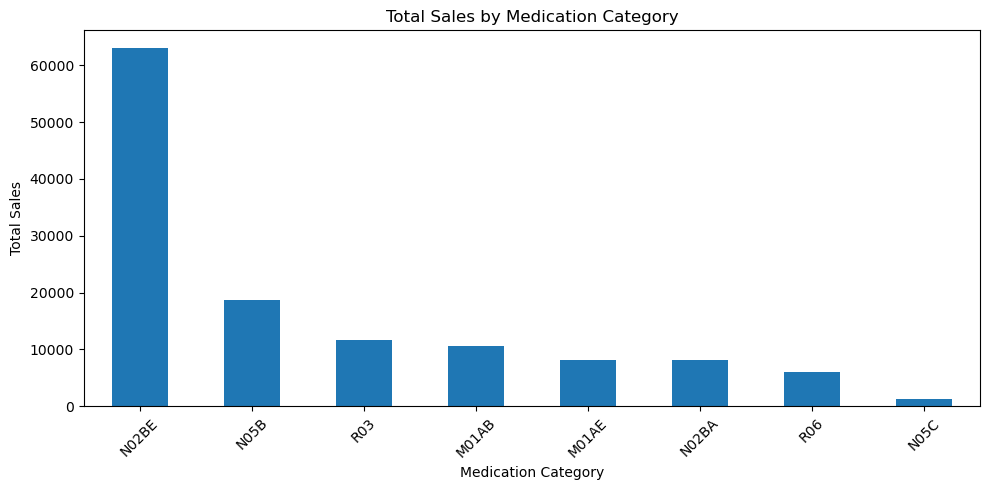

In [43]:
# Bar chart of total sales by medication category

total_sales.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Medication Category")
plt.xlabel("Medication Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

"Why did i create this visualization?"

answer:

Inventory managers need to know which medication categories contribute the most demand so they can prioritize purchasing and reduce stock shortages.

In [47]:
drug_names = {
    "M01AB": "Anti-inflammatory",
    "M01AE": "NSAIDs",
    "N02BA": "Pain Relief",
    "N02BE": "Analgesics",
    "N05B": "Anxiety Medications",
    "N05C": "Sleep Medications",
    "R03": "Asthma/COPD",
    "R06": "Antihistamines"
}

total_sales.index = total_sales.index.map(drug_names)

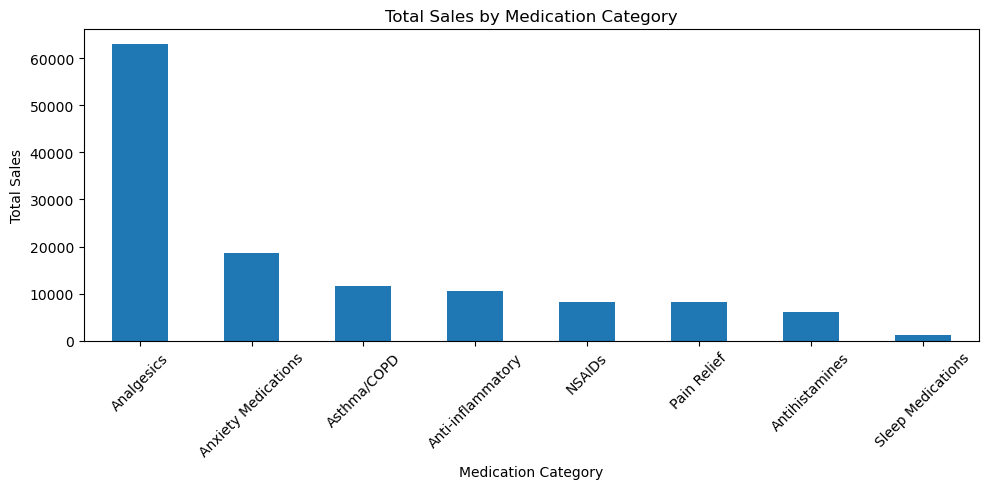

In [49]:
# Bar chart of total sales by medication category

total_sales.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Medication Category")
plt.xlabel("Medication Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Let's make the chart easier to understand. 

graph will show meaningful medication categories instead of technical ATC codes.


In [17]:
## Business Insights

### Business Insight 1

Analgesic medications recorded the highest overall sales among all medication categories, indicating consistently high customer demand. This suggests that pharmacies should prioritize maintaining adequate inventory levels for pain relief medications to minimize stock shortages.

In contrast, sleep medications showed the lowest overall sales, indicating lower demand. Pharmacy managers may consider maintaining lower inventory levels for these products to reduce excess stock and inventory holding costs.

In [56]:
##How does pharmacy demand change over time?

In [58]:
# Total daily sales across all medication categories

df["Total Sales"] = df[
    ["M01AB","M01AE","N02BA","N02BE",
     "N05B","N05C","R03","R06"]
].sum(axis=1)

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,Total Sales
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday,48.47
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday,107.00
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday,91.35
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday,66.10
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday,58.20


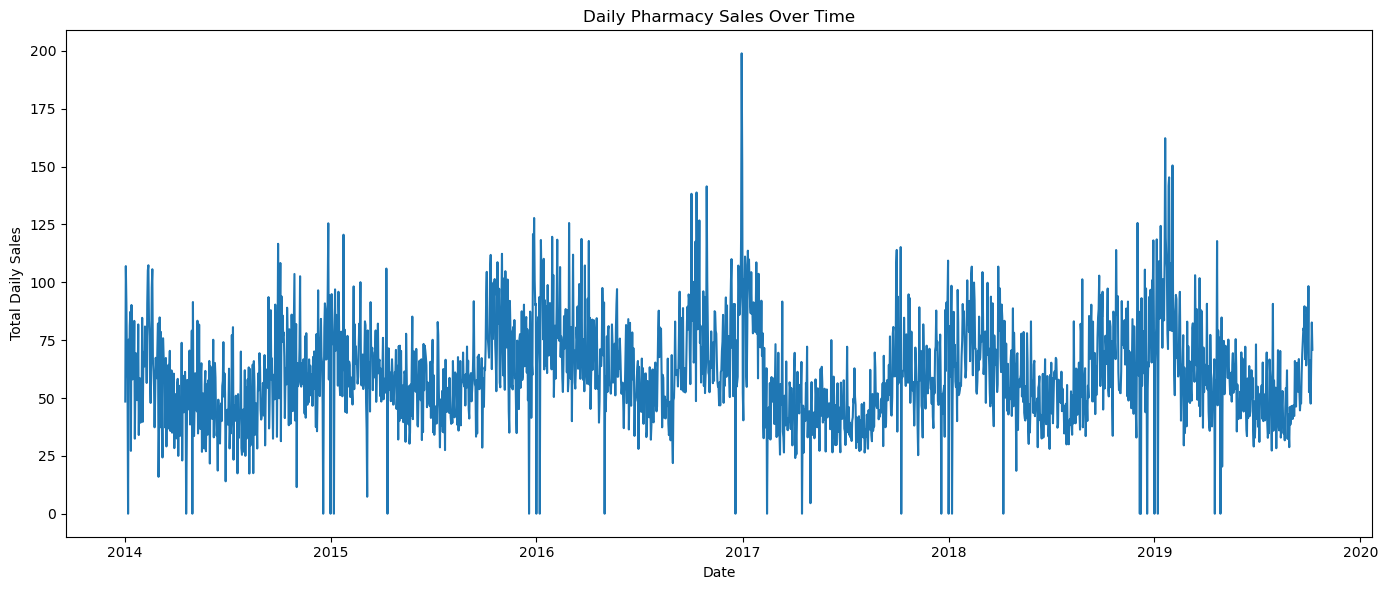

In [60]:
plt.figure(figsize=(14,6))

plt.plot(df["datum"], df["Total Sales"])

plt.title("Daily Pharmacy Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Sales")

plt.tight_layout()

plt.show()

weather, flu season, prescriptions, etc. affect demand

So up/down movement every day is NORMAL.
This is called: Short-term variability (noise)

Seasonality means: A repeating pattern over time (weekly, monthly, yearly)

Examples in pharmacy data:
winter → more cold/flu meds (R06 antihistamines)
allergy season → increase in allergy meds
weekends → sometimes lower prescription fills
flu season → spike in analgesics + respiratory drugs

Monthly Sales Trend below:

In [66]:
# Group by Year and Month

monthly_sales = df.groupby(["Year", "Month"])["Total Sales"].sum().reset_index()

monthly_sales.head()

,Year,Month,Total Sales
0,2014,1,1801.110
1,2014,2,1974.470
2,2014,3,1606.720
3,2014,4,1423.925
4,2014,5,1506.303


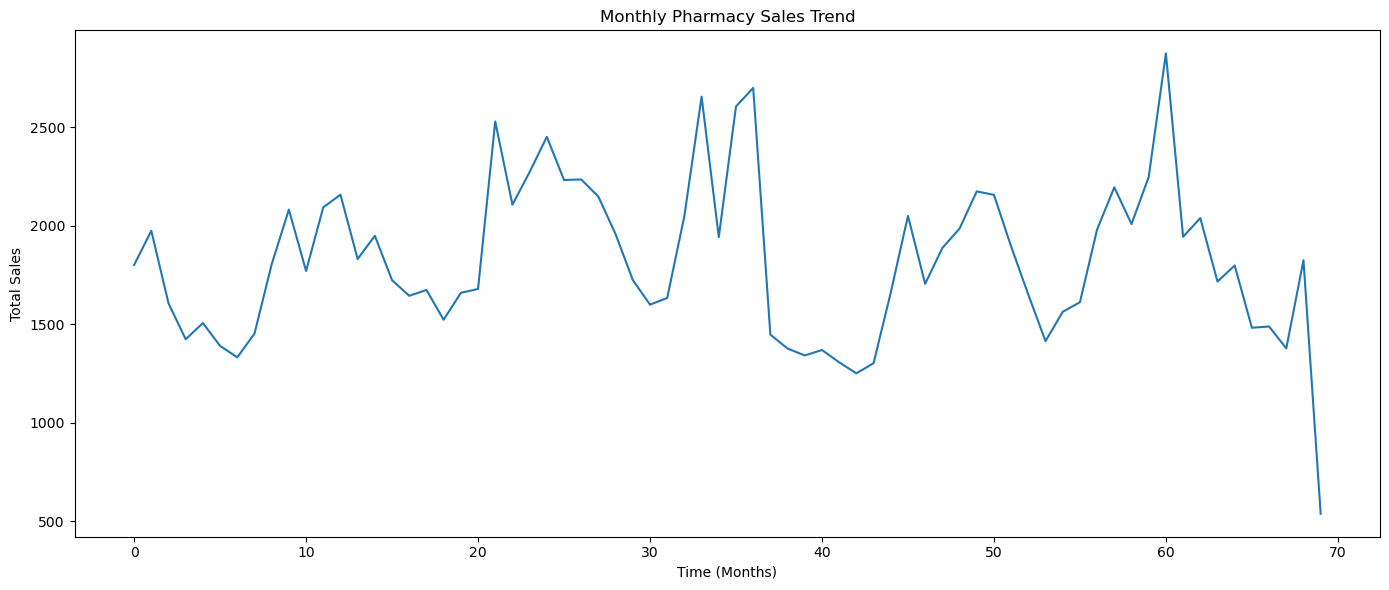

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Total Sales"])

plt.title("Monthly Pharmacy Sales Trend")
plt.xlabel("Time (Months)")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

I transformed daily transactional data into monthly aggregates to reduce noise and identify meaningful demand trends.

Even after aggregating to monthly, data still looks like:

up
down
flat
up again
dip again

This is called: Irregular fluctuation (noise in aggregated data)
1.  Real demand changes

Different medications have different needs:

pain meds → random spikes (injuries, illness)
allergy meds → seasonal spikes
sleep meds → stable/low demand

These do NOT move together → so total looks chaotic.

2. 🏪 Operational effects

Pharmacy sales are affected by:

supply availability
prescribing behavior
insurance cycles
clinic patterns

These are NOT seasonal like retail clothing or ice cream.

3. 📉 Why no clear seasonality?

Seasonality only appears when:

patterns repeat consistently every year

But your data shows:

demand is mixed across drug categories → so signals cancel out

After aggregating to monthly level, I observed that the data did not show strong seasonality, indicating that medication demand is driven more by irregular healthcare needs rather than predictable seasonal cycles.

In [72]:
##Step A: Create monthly trend per category

In [74]:
monthly_category = df.groupby(["Year", "Month"])[
    ["M01AB","M01AE","N02BA","N02BE",
     "N05B","N05C","R03","R06"]
].sum().reset_index()

monthly_category.head()

,Year,Month,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014,1,127.69,99.090,152.100,878.030,354.0,30.0,112.0,48.2
1,2014,2,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014,3,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014,4,113.10,89.475,125.150,698.500,209.0,18.0,97.0,73.7
4,2014,5,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [76]:
##Step B: Plot ONE category (clean insight)

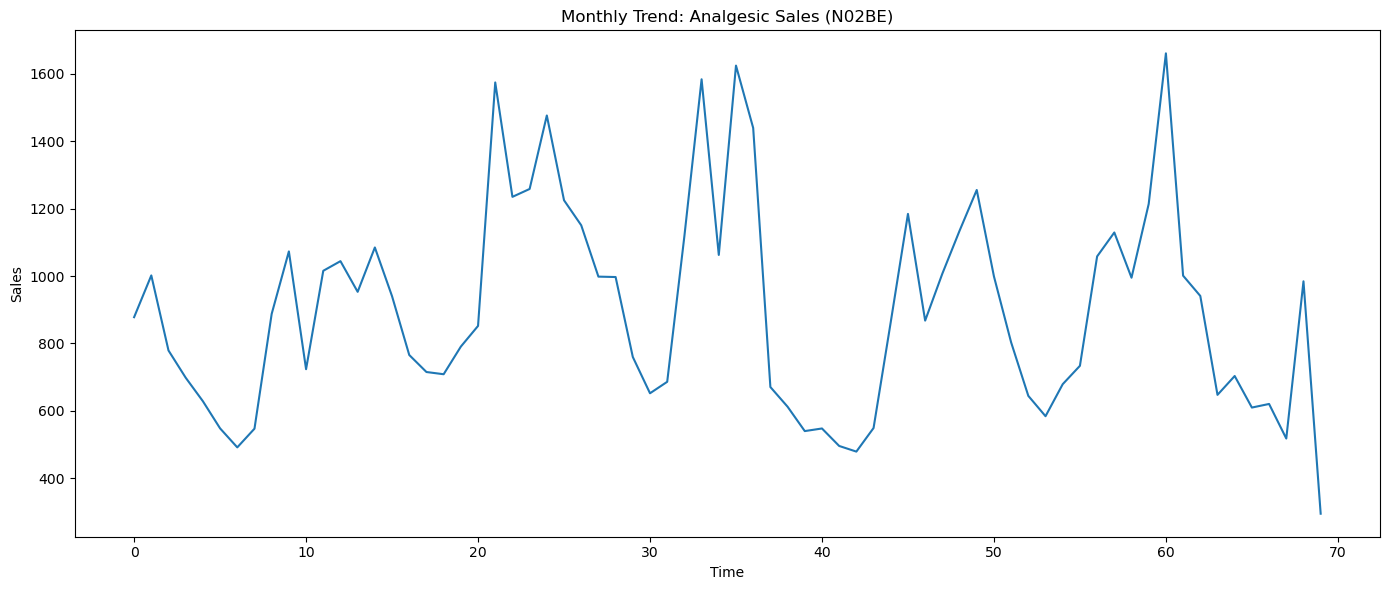

In [78]:
plt.figure(figsize=(14,6))

plt.plot(monthly_category["N02BE"])

plt.title("Monthly Trend: Analgesic Sales (N02BE)")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

Instead of analyzing total sales, I decomposed demand by therapeutic category to identify individual medication behavior patterns.”

That sentence = strong data analyst signal.
1. removed “mixed signals”

Earlier, total sales combined:

pain meds
allergy meds
asthma meds
sleep meds

Those behave differently → they cancel each other out.

Now looking at: only one demand behavior (pain relief)

So the signal becomes clearer.

 2. Why it is still “up and down pattern”

Even within one category, demand is NOT smooth because healthcare demand is:
-- Random (not scheduled): People don’t buy pain medication on a fixed calendar.

-- Event-driven : Demand increases when:
injuries happen
illness spikes
seasonal flu occurs
prescription timing varies

-- Supply + prescribing variability: Doctors + pharmacies + refills create fluctuations

 Final interpretation: 
 graph really shows is:

Analgesic demand has an overall fluctuating pattern driven by irregular healthcare events rather than predictable seasonal cycles. While aggregating by category reduces noise compared to total sales, short-term variability remains due to event-driven medication usage.”

### Business Insight 2

Analgesic medication demand shows a clearer trend when analyzed separately from total pharmacy sales. However, the pattern still exhibits irregular fluctuations, indicating that demand is largely driven by unpredictable healthcare events such as injuries and short-term illnesses rather than consistent seasonal cycles.

This suggests that pharmacies should maintain stable inventory levels for high-demand pain medications, as demand spikes are difficult to predict but occur frequently.

In [ ]:
##Which medication categories are most stable vs most volatile?

In [82]:
##Volatility Analysis : how “unstable” each category is
drug_columns = ["M01AB","M01AE","N02BA","N02BE",
                "N05B","N05C","R03","R06"]

volatility = df[drug_columns].std().sort_values(ascending=False)

volatility

N02BE    15.590966
R03       6.428736
N05B      5.605605
M01AB     2.737579
R06       2.415816
N02BA     2.384010
M01AE     2.133337
N05C      1.092988
dtype: float64

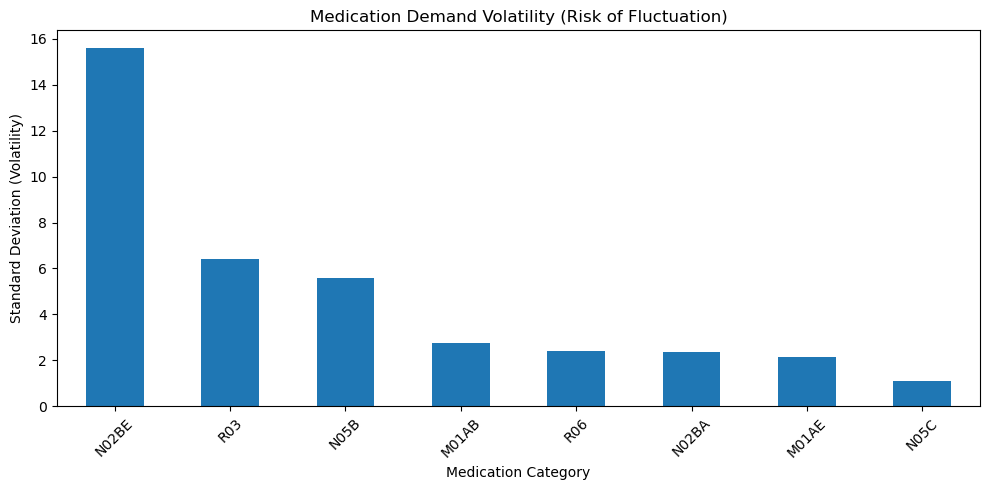

In [84]:
volatility.plot(kind="bar", figsize=(10,5))

plt.title("Medication Demand Volatility (Risk of Fluctuation)")
plt.xlabel("Medication Category")
plt.ylabel("Standard Deviation (Volatility)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Highest volatility (most unstable demand)
N02BE = 15.59

 This means:

analgesic demand is highly variable
frequent spikes (injuries, illness events, prescriptions)
Medium volatility
R03 = 6.43 → asthma/COPD meds
N05B = 5.60 → anxiety meds

 These have:

periodic demand changes
some seasonality or episodic use

### Business Insight 3

Demand volatility varies significantly across medication categories. Analgesic medication (N02BE) shows the highest variability, indicating frequent and unpredictable demand spikes likely driven by short-term medical events such as injuries or acute illness.

In contrast, categories such as N05C and M01AE demonstrate relatively stable demand patterns, making them easier to forecast and manage from an inventory planning perspective.

These findings suggest that pharmacies should adopt different inventory strategies depending on medication volatility, maintaining higher safety stock for high-variance drugs and optimizing lower stock levels for stable-demand categories.

In [88]:
## Do people buy more medications on certain days?

In [90]:
## Create weekday analysis
weekday_sales = df.groupby("Weekday Name")["Total Sales"].mean().reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

weekday_sales

Weekday Name
Monday       60.607364
Tuesday      60.017432
Wednesday    59.238425
Thursday     57.184018
Friday       60.247480
Saturday     65.673071
Sunday       61.134343
Name: Total Sales, dtype: float64

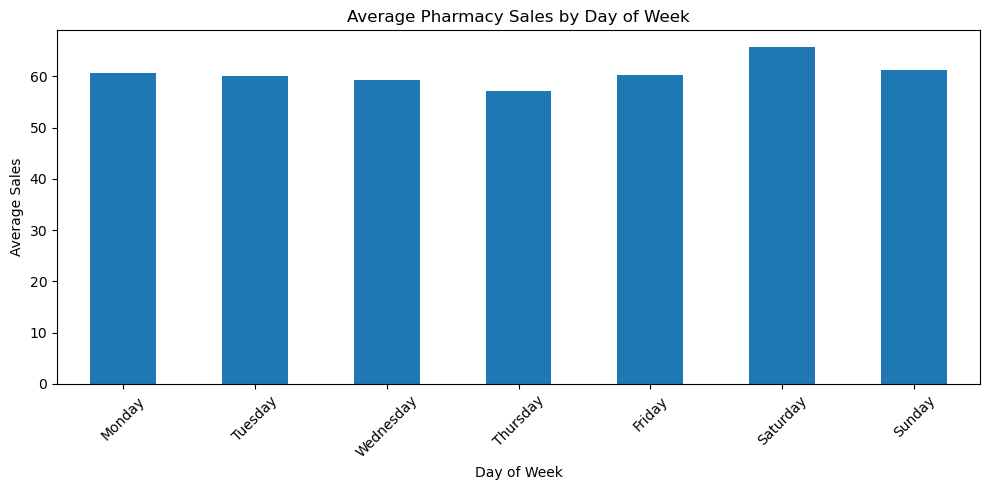

In [92]:
# plot

weekday_sales.plot(kind="bar", figsize=(10,5))

plt.title("Average Pharmacy Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

ifound:

Saturday = highest (~65.7)
Thursday = lowest (~57.2)
All other days ≈ very similar (~59–61)

So the key pattern is:

There is NO strong weekday effect — demand is fairly stable across the week.
Why this happens (real pharmacy logic)

Unlike retail stores or restaurants, pharmacy demand is:

1. Need-based, not lifestyle-based

People don’t choose medication based on the day of the week.

pain → happens any day
asthma → chronic, daily
allergies → seasonal, not weekday-driven

So demand stays stable.

2. Prescription refill cycles smooth everything out

Pharmacies often have:

automatic refills
insurance-driven pickup schedules
doctor-controlled prescriptions

This spreads demand evenly across days.

3. 📈 Why Saturday is slightly higher

Your result shows Saturday is highest — this is realistic because:

people are off work → more time to pick up prescriptions
clinics may give weekend prescriptions
delayed weekday pickups happen on weekends

But the difference is still small → so it’s not a strong effect.

### Business Insight 4

Average pharmacy sales remain relatively stable across weekdays, indicating that medication demand is not strongly influenced by day-of-week patterns. This suggests that pharmaceutical demand is primarily driven by medical necessity rather than consumer behavior or timing preferences.

A slight increase in sales on Saturdays may reflect increased patient availability for prescription pickups during weekends, but the overall variation across days is minimal.

These findings imply that staffing and inventory levels can remain consistent throughout the week with only minor adjustments for weekend demand.

In [ ]:
## Build monthly dataset (category-wise)

In [96]:
monthly_category = df.groupby("Month")[
    ["M01AB","M01AE","N02BA","N02BE",
     "N05B","N05C","R03","R06"]
].mean()

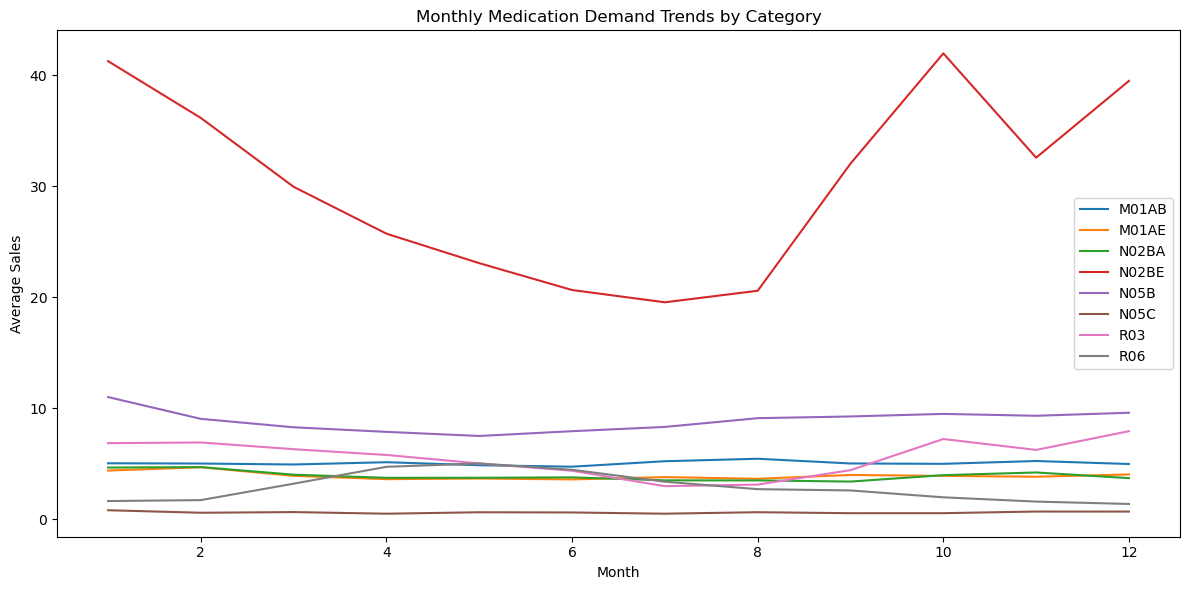

In [98]:
## plot 
monthly_category.plot(figsize=(12,6))

plt.title("Monthly Medication Demand Trends by Category")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

What this REALLY means

 N02BE has much higher demand than all others

So your pharmacy demand is:

highly concentrated in one medication category


2. Other categories look “flat” because of scale

 plotting everything on the same y-axis

So what happens:

N02BE = large values → big visible waves
others = small values → get visually compressed near zero

👉 They are NOT actually flat
👉 They are just small compared to N02BE

3. Business meaning of this pattern
🔴 High dependency risk

If N02BE supply breaks:

pharmacy demand impact is huge
🟠 Low-volume categories
stable, predictable
easier to manage inventory

### Business Insight 5

Medication demand is highly concentrated in a single therapeutic category (N02BE - analgesics), which dominates overall sales volume. This indicates that pharmacy operations are heavily influenced by pain-relief medications compared to other drug categories.

Other medication categories show relatively low and stable demand patterns when plotted on the same scale, suggesting lower contribution to overall sales and more predictable inventory requirements.

This concentration highlights the importance of maintaining sufficient stock levels for high-demand categories to prevent supply shortages and ensure continuous patient care.

In [ ]:
## Normalize data

In [101]:
monthly_category_norm = monthly_category.copy()

monthly_category_norm = monthly_category_norm / monthly_category_norm.max()

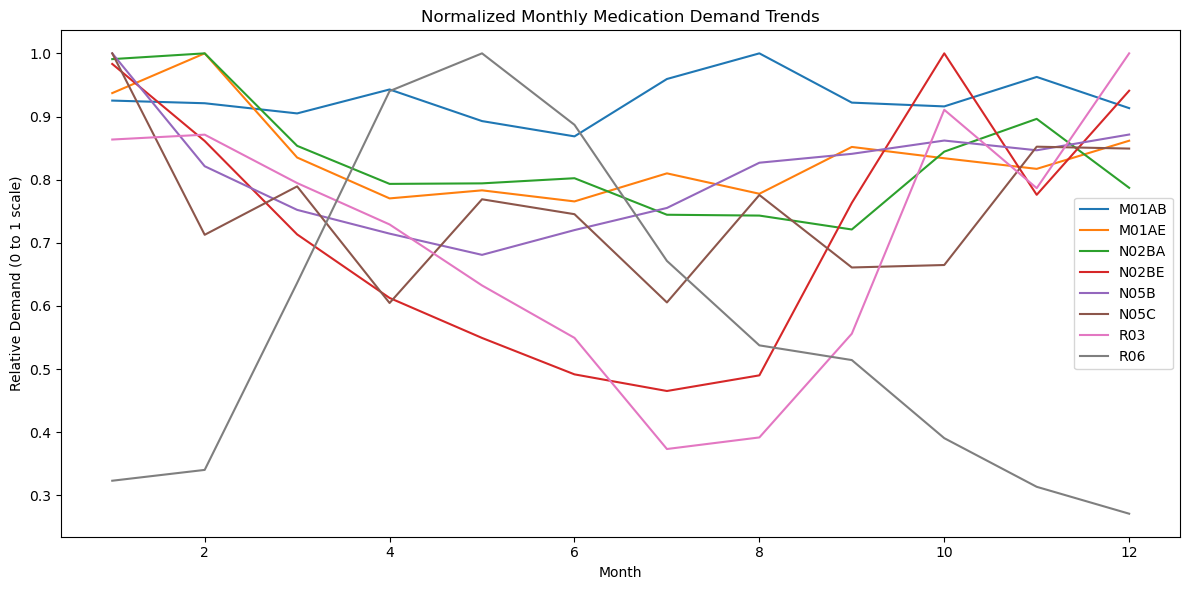

In [103]:
## plot
monthly_category_norm.plot(figsize=(12,6))

plt.title("Normalized Monthly Medication Demand Trends")
plt.xlabel("Month")
plt.ylabel("Relative Demand (0 to 1 scale)")

plt.tight_layout()
plt.show()

Before normalization:
N02BE dominated everything
others looked flat

After normalization:
all categories are on the same scale
differences in pattern shape become visible

Why it now looks “mixed and colorful”

Because:

1. Different behavior patterns at the same scale

Each drug category has its own demand “personality”:

some fluctuate randomly
some are slightly stable
some have mild peaks

So lines overlap and cross → it looks messy

2. No strong synchronized pattern exists

If this were seasonal retail data, then:

all lines go up in winter
all lines go down in summer

But here:

each medication behaves independently

So the chart looks chaotic.


Pharmacy demand is multi-driver and non-synchronized across categories.

That means:

no universal seasonal pattern
each medication category has independent demand behavior
total demand is a combination of unrelated signals

### Business Insight 6

After normalizing all medication categories to a common scale, it becomes clear that each category follows an independent demand pattern. Unlike industries with strong seasonal synchronization, pharmacy demand is driven by multiple unrelated factors such as illness type, prescriptions, and patient needs.

The lack of synchronized movement across categories suggests that overall pharmacy sales are an aggregation of independent demand signals rather than a unified seasonal trend.

In [19]:
## Conclusion

## Final Business Summary

This project analyzed multi-year pharmacy sales data across multiple therapeutic medication categories to understand demand patterns, volatility, and inventory implications.

Key findings from the analysis include:

- Analgesic medications (N02BE) represent the highest demand category, indicating strong and consistent usage for pain-related conditions.
- Medication demand shows high variability across categories, with some drugs exhibiting stable demand while others fluctuate significantly due to irregular healthcare events.
- No strong weekday-based seasonality was observed, suggesting that pharmacy demand is driven by medical necessity rather than consumer behavior patterns.
- Demand patterns are independent across categories, indicating that pharmacy sales are an aggregation of multiple unrelated medical needs rather than a unified seasonal trend.

Overall, the analysis highlights the importance of category-specific inventory planning, with higher safety stock required for high-demand and high-volatility medications.

Author: shweta sharma